ya vimos la estructura temporal de los accesos y descubrimos que "crecimiento" no necesariamente significa crecimiento sostenido.
las preguntas que queremos responder viendo lo que nos pudo arrojar los datos durante el proceso de exploración fueron los siguientes:

1. ¿Cómo ha evolucionado la conectividad en Colombia?

  | ¿Cómo ha evolucionado el acceso a internet en Colombia entre 2017 y 2025 y qué tan sostenido ha sido ese crecimiento?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
from pathlib import Path

ruta = Path("../data/raw")

df1 = pd.read_csv(ruta / "ACCESOS_INTERNET_FIJO_2_8.csv", sep=";")

df2 = pd.read_csv(ruta / "ACCESOS_INTERNET_FIJO_3_5.csv", sep=";")

# Base temporal para comparar el cuarto trimestre de cada año.

df_q4 = df1[df1["TRIMESTRE"] == 4].copy()

accesos_anuales = (

    df1.groupby("ANNO", as_index=False)["ACCESOS"]

    .sum()

)

accesos_q4 = (

    df_q4.groupby("ANNO", as_index=False)["ACCESOS"]

    .sum()

)

accesos_q4["CAMBIO_ABSOLUTO"] = accesos_q4["ACCESOS"].diff()

accesos_q4["CAMBIO_PORCENTUAL"] = accesos_q4["ACCESOS"].pct_change() * 100

residenciales = df1[

    df1["SEGMENTO"].str.startswith("Residencial")

].copy()

residenciales_q4 = residenciales[

    residenciales["TRIMESTRE"] == 4

].copy()

estrato_q4 = (

    residenciales_q4

    .groupby(["ANNO", "SEGMENTO"], as_index=False)["ACCESOS"]

    .sum()

)

estrato_pivot = estrato_q4.pivot(

    index="ANNO", columns="SEGMENTO", values="ACCESOS"

)

cambio_estrato = pd.DataFrame({

    "accesos_2017": estrato_pivot.loc[2017],

    "accesos_2025": estrato_pivot.loc[2025]

})

cambio_estrato["cambio_absoluto"] = (

    cambio_estrato["accesos_2025"] - cambio_estrato["accesos_2017"]

)

cambio_estrato["cambio_%"] = (

    cambio_estrato["accesos_2025"] / cambio_estrato["accesos_2017"] - 1

) * 100

municipal_q4 = (

    residenciales_q4

    .groupby(

        [

            "ID_MUNICIPIO",

            "MUNICIPIO",

            "ID_DEPARTAMENTO",

            "DEPARTAMENTO",

            "ANNO"

        ],

        as_index=False

    )["ACCESOS"]

    .sum()

)

municipios_pivot = (

    municipal_q4

    .pivot_table(

        index=[

            "ID_MUNICIPIO",

            "MUNICIPIO",

            "ID_DEPARTAMENTO",

            "DEPARTAMENTO"

        ],

        columns="ANNO",

        values="ACCESOS",

        fill_value=0

    )

    .reset_index()

)

municipios_pivot.columns.name = None

municipios_pivot = municipios_pivot.rename(

    columns={2017: "ACCESOS_2017", 2025: "ACCESOS_2025"}

)

ranking_municipios = municipios_pivot[

    (municipios_pivot["ACCESOS_2017"] > 0)

    & (municipios_pivot["ACCESOS_2025"] > 0)

].copy()

ranking_municipios["CAMBIO_ABSOLUTO"] = (

    ranking_municipios["ACCESOS_2025"] - ranking_municipios["ACCESOS_2017"]

)

ranking_municipios["CAMBIO_%"] = (

    ranking_municipios["CAMBIO_ABSOLUTO"]

    / ranking_municipios["ACCESOS_2017"]

) * 100

top_crecimiento = (

    ranking_municipios.sort_values("CAMBIO_%", ascending=False)

    [[

        "MUNICIPIO", "DEPARTAMENTO", "ACCESOS_2017", "ACCESOS_2025",

        "CAMBIO_ABSOLUTO", "CAMBIO_%"

    ]]

    .head(20)

)

top_absoluto = (

    ranking_municipios.sort_values("CAMBIO_ABSOLUTO", ascending=False)

    [[

        "MUNICIPIO", "DEPARTAMENTO", "ACCESOS_2017", "ACCESOS_2025",

        "CAMBIO_ABSOLUTO", "CAMBIO_%"

    ]]

    .head(20)

)

In [3]:
accesos_q4

,ANNO,ACCESOS,CAMBIO_ABSOLUTO,CAMBIO_PORCENTUAL
0,2017,6352946,NaN,NaN
1,2018,6731666,"378,720.00",5.96
2,2019,6984242,"252,576.00",3.75
3,2020,7837355,"853,113.00",12.21
4,2021,8454845,"617,490.00",7.88
5,2022,8841612,"386,767.00",4.57
6,2023,9064552,"222,940.00",2.52
7,2024,9278294,"213,742.00",2.36
8,2025,10325111,"1,046,817.00",11.28


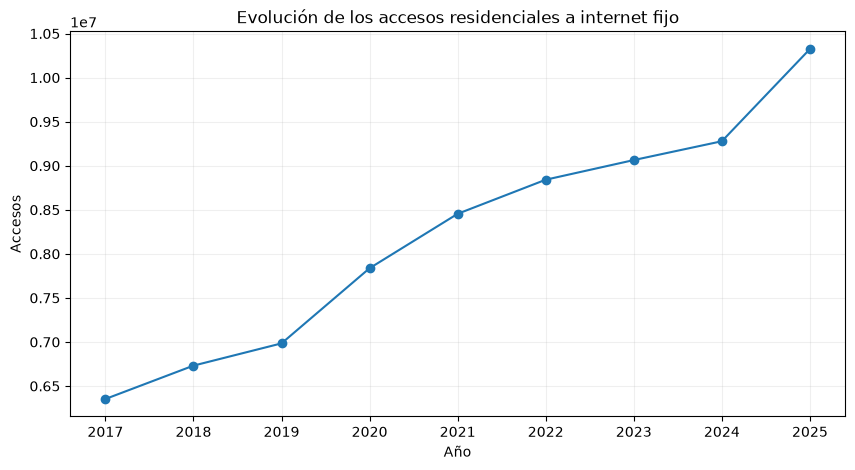

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(
    accesos_q4["ANNO"],
    accesos_q4["ACCESOS"],
    marker="o"
)

plt.title("Evolución de los accesos residenciales a internet fijo")
plt.xlabel("Año")
plt.ylabel("Accesos")
plt.grid(alpha=0.2)

plt.show()

In [5]:
inicio = accesos_q4.loc[accesos_q4["ANNO"] == 2017, "ACCESOS"].iloc[0]
fin = accesos_q4.loc[accesos_q4["ANNO"] == 2025, "ACCESOS"].iloc[0]

crecimiento = (fin / inicio - 1) * 100

inicio, fin, crecimiento

(np.int64(6352946), np.int64(10325111), np.float64(62.5247719719324))

dónde estuvo realmente el crecimiento

In [6]:
crecimiento_nacional = (
    accesos_q4.loc[accesos_q4["ANNO"] == 2025, "ACCESOS"].iloc[0]
    - accesos_q4.loc[accesos_q4["ANNO"] == 2017, "ACCESOS"].iloc[0]
)

crecimiento_nacional

np.int64(3972165)

In [7]:
municipal_q4 = (
    df_q4[
        df_q4["SEGMENTO"].str.startswith("Residencial")
    ]
    .groupby(
        [
            "ID_MUNICIPIO",
            "MUNICIPIO",
            "ID_DEPARTAMENTO",
            "DEPARTAMENTO",
            "ANNO"
        ],
        as_index=False
    )["ACCESOS"]
    .sum()
)

municipios_pivot = (
    municipal_q4
    .pivot_table(
        index=[
            "ID_MUNICIPIO",
            "MUNICIPIO",
            "ID_DEPARTAMENTO",
            "DEPARTAMENTO"
        ],
        columns="ANNO",
        values="ACCESOS",
        fill_value=0
    )
    .reset_index()
)

municipios_pivot.columns.name = None

municipios_pivot = municipios_pivot.rename(
    columns={
        2017: "ACCESOS_2017",
        2025: "ACCESOS_2025"
    }
)

ranking_municipios = municipios_pivot[
    (municipios_pivot["ACCESOS_2017"] > 0) &
    (municipios_pivot["ACCESOS_2025"] > 0)
].copy()

ranking_municipios["CAMBIO_ABSOLUTO"] = (
    ranking_municipios["ACCESOS_2025"]
    - ranking_municipios["ACCESOS_2017"]
)

ranking_municipios["CAMBIO_%"] = (
    ranking_municipios["CAMBIO_ABSOLUTO"]
    / ranking_municipios["ACCESOS_2017"]
) * 100

In [8]:
ranking_municipios["CAMBIO_ABSOLUTO"].sum()

np.float64(2656733.0)

In [9]:
crecimiento_nacional = (
    accesos_q4.loc[accesos_q4["ANNO"] == 2025, "ACCESOS"].iloc[0]
    - accesos_q4.loc[accesos_q4["ANNO"] == 2017, "ACCESOS"].iloc[0]
)

crecimiento_nacional

np.int64(3972165)

In [10]:
ranking_municipios["APORTE_CRECI_NACIONAL_%"] = (
    ranking_municipios["CAMBIO_ABSOLUTO"]
    / crecimiento_nacional
) * 100

In [11]:
ranking_municipios.sort_values(
    "APORTE_CRECI_NACIONAL_%",
    ascending=False
)[[
    "MUNICIPIO",
    "DEPARTAMENTO",
    "CAMBIO_ABSOLUTO",
    "APORTE_CRECI_NACIONAL_%"
]].head(20)

,MUNICIPIO,DEPARTAMENTO,CAMBIO_ABSOLUTO,APORTE_CRECI_NACIONAL_%
0,MEDELLÍN,ANTIOQUIA,"255,935.00",6.44
158,CARTAGENA,BOLÍVAR,"120,100.00",3.02
579,SOACHA,CUNDINAMARCA,"106,536.00",2.68
1050,IBAGUÉ,TOLIMA,"97,271.00",2.45
1099,CALI,VALLE DEL CAUCA,"96,916.00",2.44
133,BARRANQUILLA,ATLÁNTICO,"84,883.00",2.14
18,BELLO,ANTIOQUIA,"81,427.00",2.05
696,SANTA MARTA,MAGDALENA,"54,749.00",1.38
919,PEREIRA,RISARALDA,"48,140.00",1.21
434,VALLEDUPAR,CESAR,"46,706.00",1.18


In [12]:
crecimiento_residencial = (
    residenciales_q4
    .groupby("ANNO")["ACCESOS"]
    .sum()
)

crecimiento_residencial

ANNO
2017    5760591
2018    6091471
2019    6355385
2020    7206429
2021    7706886
2022    7922396
2023    8135705
2024    8325462
2025    9274043
Name: ACCESOS, dtype: int64

In [13]:
crecimiento_residencial.loc[2025] - crecimiento_residencial.loc[2017]

np.int64(3513452)

In [14]:
crecimiento_residencial.loc[2025] - crecimiento_residencial.loc[2017] - ranking_municipios["CAMBIO_ABSOLUTO"].sum()

np.float64(856719.0)

In [15]:
# Comparar crecimiento nacional vs crecimiento municipal
crecimiento_nacional = (
    residenciales_q4
    .groupby("ANNO")["ACCESOS"]
    .sum()
)

crecimiento_municipal = (
    municipal_q4
    .groupby("ANNO")["ACCESOS"]
    .sum()
)

comparacion = pd.DataFrame({
    "NACIONAL": crecimiento_nacional,
    "MUNICIPAL": crecimiento_municipal
})

comparacion["DIFERENCIA"] = (
    comparacion["NACIONAL"] - comparacion["MUNICIPAL"]
)

comparacion

,NACIONAL,MUNICIPAL,DIFERENCIA
ANNO,,,
2017,5760591,5760591,0
2018,6091471,6091471,0
2019,6355385,6355385,0
2020,7206429,7206429,0
2021,7706886,7706886,0
2022,7922396,7922396,0
2023,8135705,8135705,0
2024,8325462,8325462,0
2025,9274043,9274043,0


In [16]:
municipios_pivot

,ID_MUNICIPIO,MUNICIPIO,ID_DEPARTAMENTO,DEPARTAMENTO,ACCESOS_2017,2018,2019,2020,2021,2022,2023,2024,ACCESOS_2025
0,5001,MEDELLÍN,5,ANTIOQUIA,"519,915.00","541,053.00","565,883.00","613,323.00","634,819.00","678,288.00","681,466.00","702,155.00","775,850.00"
1,5002,ABEJORRAL,5,ANTIOQUIA,795.00,908.00,941.00,"24,625.00","2,129.00","2,220.00",843.00,546.00,338.00
2,5004,ABRIAQUÍ,5,ANTIOQUIA,45.00,52.00,65.00,114.00,136.00,130.00,94.00,63.00,43.00
3,5021,ALEJANDRÍA,5,ANTIOQUIA,246.00,280.00,265.00,184.00,290.00,253.00,264.00,344.00,320.00
4,5030,AMAGÁ,5,ANTIOQUIA,"2,355.00","2,761.00","2,916.00","2,787.00","3,539.00","3,240.00","3,969.00","4,545.00","4,528.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1206,97666,TARAIRA,97,VAUPÉS,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
1207,99001,PUERTO CARREÑO,99,VICHADA,"2,036.00",769.00,"1,045.00","1,245.00","1,059.00",884.00,560.00,277.00,222.00
1208,99524,LA PRIMAVERA,99,VICHADA,0.00,0.00,2.00,0.00,0.00,10.00,0.00,0.00,24.00
1209,99624,SANTA ROSALÍA,99,VICHADA,0.00,0.00,1.00,0.00,0.00,10.00,0.00,0.00,45.00


In [17]:
municipios_excluidos = municipios_pivot[
    (municipios_pivot["ACCESOS_2017"] == 0) |
    (municipios_pivot["ACCESOS_2025"] == 0)
].copy()

municipios_excluidos["CAMBIO_ABSOLUTO"] = (
    municipios_excluidos["ACCESOS_2025"]
    - municipios_excluidos["ACCESOS_2017"]
)

municipios_excluidos.sort_values(
    "CAMBIO_ABSOLUTO",
    ascending=False
).head(20)

,ID_MUNICIPIO,MUNICIPIO,ID_DEPARTAMENTO,DEPARTAMENTO,ACCESOS_2017,2018,2019,2020,2021,2022,2023,2024,ACCESOS_2025,CAMBIO_ABSOLUTO
156,11001,BOGOTÁ,11,BOGOTÁ D.C.,0.00,0.00,0.00,0.00,0.00,"2,022,078.00","2,010,921.00","2,102,857.00","2,250,053.00","2,250,053.00"
826,54001,CÚCUTA,54,NORTE SANTANDER,0.00,0.00,0.00,0.00,0.00,"109,595.00","114,444.00","112,261.00","132,385.00","132,385.00"
61,5360,ITAGUÍ,5,ANTIOQUIA,0.00,0.00,0.00,0.00,0.00,"79,119.00","80,001.00","85,951.00","93,114.00","93,114.00"
358,18001,FLORENCIA,18,CAQUETÁ,0.00,0.00,0.00,0.00,0.00,"24,123.00","21,743.00","22,415.00","25,974.00","25,974.00"
869,54405,LOS PATIOS,54,NORTE SANTANDER,0.00,0.00,0.00,0.00,0.00,"16,756.00","17,697.00","18,108.00","21,656.00","21,656.00"
875,54498,OCAÑA,54,NORTE SANTANDER,0.00,0.00,0.00,0.00,0.00,"9,184.00","4,812.00","10,409.00","21,572.00","21,572.00"
905,54874,VILLA DEL ROSARIO,54,NORTE SANTANDER,0.00,0.00,0.00,0.00,0.00,"16,378.00","16,739.00","17,186.00","20,416.00","20,416.00"
1183,88001,SAN ANDRÉS,88,SAN ANDRÉS,0.00,0.00,0.00,0.00,0.00,"5,978.00","10,571.00","11,532.00","12,310.00","12,310.00"
909,63130,CALARCÁ,63,QUINDÍO,0.00,0.00,0.00,0.00,0.00,"11,215.00","12,444.00","11,368.00","12,188.00","12,188.00"
598,25843,VILLA DE SAN DIEGO DE UBATÉ,25,CUNDINAMARCA,0.00,0.00,0.00,0.00,0.00,"7,762.00","10,496.00","9,051.00","9,903.00","9,903.00"


In [18]:
municipios_excluidos.shape

(337, 14)

In [19]:
df1[
    df1["MUNICIPIO"].isin([
        "BOGOTÁ",
        "CÚCUTA",
        "ITAGÜÍ"
    ])
][
    [
        "ANNO",
        "TRIMESTRE",
        "MUNICIPIO",
        "SEGMENTO",
        "ACCESOS"
    ]
].sort_values(
    ["MUNICIPIO", "ANNO", "TRIMESTRE", "SEGMENTO"]
).head(100)

,ANNO,TRIMESTRE,MUNICIPIO,SEGMENTO,ACCESOS
1418581,2022,1,BOGOTÁ,Corporativo,1
1418582,2022,1,BOGOTÁ,Corporativo,1
1419897,2022,1,BOGOTÁ,Corporativo,6
1419898,2022,1,BOGOTÁ,Corporativo,1
1419899,2022,1,BOGOTÁ,Corporativo,2
...,...,...,...,...,...
1425364,2022,1,BOGOTÁ,Corporativo,197
1425365,2022,1,BOGOTÁ,Corporativo,72
1425366,2022,1,BOGOTÁ,Corporativo,5
1425367,2022,1,BOGOTÁ,Corporativo,2


In [20]:
df1[
    df1["MUNICIPIO"].isin([
        "BOGOTÁ",
        "CÚCUTA",
        "ITAGÜÍ"
    ])
]["SEGMENTO"].unique()

<ArrowStringArray>
[           'Residencial - Estrato 1',            'Residencial - Estrato 2',
            'Residencial - Estrato 3',            'Residencial - Estrato 4',
                        'Corporativo',            'Residencial - Estrato 5',
            'Residencial - Estrato 6',    'Uso propio interno del operador',
                   'Sin estratificar', 'Corporativo  (accesos adicionales)']
Length: 10, dtype: str

2. ¿Qué diferencia existe entre cabeceras y zonas rurales?

¿Qué brechas existen entre las cabeceras municipales y las zonas rurales en el acceso a internet?

In [22]:
%whos

Variable                  Type           Data/Info
--------------------------------------------------
Path                      type           <class 'pathlib.Path'>
accesos_anuales           DataFrame      Shape: (10, 2)
accesos_q4                DataFrame      Shape: (9, 4)
cambio_estrato            DataFrame      Shape: (6, 4)
comparacion               DataFrame      Shape: (9, 3)
crecimiento               float64        62.5247719719324
crecimiento_municipal     Series         Shape: (9,)
crecimiento_nacional      Series         Shape: (9,)
crecimiento_residencial   Series         Shape: (9,)
df1                       DataFrame      Shape: (3288251, 15)
df2                       DataFrame      Shape: (973335, 15)
df_q4                     DataFrame      Shape: (822654, 15)
estrato_pivot             DataFrame      Shape: (9, 6)
estrato_q4                DataFrame      Shape: (54, 3)
fin                       int64          10325111
inicio                    int64          6352946
mu

No tenemos suficiente datos para responder la pregunta 2, la dejaré para un futuro analisis. 

3. ¿Qué territorios presentan las mayores brechas?

¿Qué territorios presentan los menores niveles de acceso a internet y cuáles concentran las mayores brechas territoriales?

In [23]:
df2.columns.tolist()

['ANNO',
 'TRIMESTRE',
 'ID_EMPRESA',
 'EMPRESA',
 'ID_MUNICIPIO',
 'MUNICIPIO',
 'ID_DEPARTAMENTO',
 'DEPARTAMENTO',
 'ID_SEGMENTO',
 'SEGMENTO',
 'VELOCIDAD_EFECTIVA_DOWNSTREAM',
 'VELOCIDAD_EFECTIVA_UPSTREAM',
 'ID_TECNOLOGIA',
 'TECNOLOGIA',
 'ACCESOS']

accesos residenciales por municipio en 2025

In [25]:
municipios_2025 = (
    residenciales_q4[residenciales_q4["ANNO"] == 2025]
    .groupby(
        ["ID_MUNICIPIO", "MUNICIPIO", "ID_DEPARTAMENTO", "DEPARTAMENTO"],
        as_index=False
    )["ACCESOS"]
    .sum()
    .sort_values("ACCESOS")
)

municipios_2025.head(20)

,ID_MUNICIPIO,MUNICIPIO,ID_DEPARTAMENTO,DEPARTAMENTO,ACCESOS
768,54125,CÁCOTA,54,NORTE SANTANDER,1
786,54480,MUTISCUA,54,NORTE SANTANDER,1
741,52520,FRANCISCO PIZARRO,52,NARIÑO,1
541,25807,TIBIRITA,25,CUNDINAMARCA,1
574,27372,JURADÓ,27,CHOCÓ,1
781,54377,LABATECA,54,NORTE SANTANDER,1
208,15135,CAMPOHERMOSO,15,BOYACÁ,1
897,68720,SANTA HELENA DEL OPÓN,68,SANTANDER,1
488,25339,GUTIÉRREZ,25,CUNDINAMARCA,1
896,68705,SANTA BÁRBARA,68,SANTANDER,1


In [26]:
municipios_2025["ACCESOS"].describe()

count       1,077.00
mean        8,611.00
std        76,756.89
min             1.00
25%           169.00
50%           598.00
75%         2,045.00
max     2,250,053.00
Name: ACCESOS, dtype: float64

cuántos municipios están por debajo de ciertos umbrales.

In [27]:
umbrales = [10, 50, 100, 500, 1000, 2000]

for u in umbrales:
    n = (municipios_2025["ACCESOS"] <= u).sum()
    print(f"{u:>5} accesos o menos: {n} municipios ({n/len(municipios_2025)*100:.1f}%)")

   10 accesos o menos: 51 municipios (4.7%)
   50 accesos o menos: 142 municipios (13.2%)
  100 accesos o menos: 207 municipios (19.2%)
  500 accesos o menos: 486 municipios (45.1%)
 1000 accesos o menos: 659 municipios (61.2%)
 2000 accesos o menos: 801 municipios (74.4%)


In [28]:
# Accesos residenciales por municipio en 2025

municipios_2025 = municipios_pivot[
    ["ID_MUNICIPIO", "MUNICIPIO", "DEPARTAMENTO", "ACCESOS_2025"]
].copy()

# Umbrales que queremos analizar
umbrales = [10, 50, 100, 500, 1000, 2000]

# Total de municipios
total_municipios = len(municipios_2025)

# Calcular cantidad y porcentaje
distribucion = []

for umbral in umbrales:
    cantidad = (municipios_2025["ACCESOS_2025"] <= umbral).sum()
    porcentaje = cantidad / total_municipios * 100
    
    distribucion.append({
        "UMBRAL": umbral,
        "MUNICIPIOS": cantidad,
        "PORCENTAJE": porcentaje
    })

distribucion = pd.DataFrame(distribucion)

distribucion

,UMBRAL,MUNICIPIOS,PORCENTAJE
0,10,185,15.28
1,50,276,22.79
2,100,341,28.16
3,500,620,51.20
4,1000,793,65.48
5,2000,935,77.21


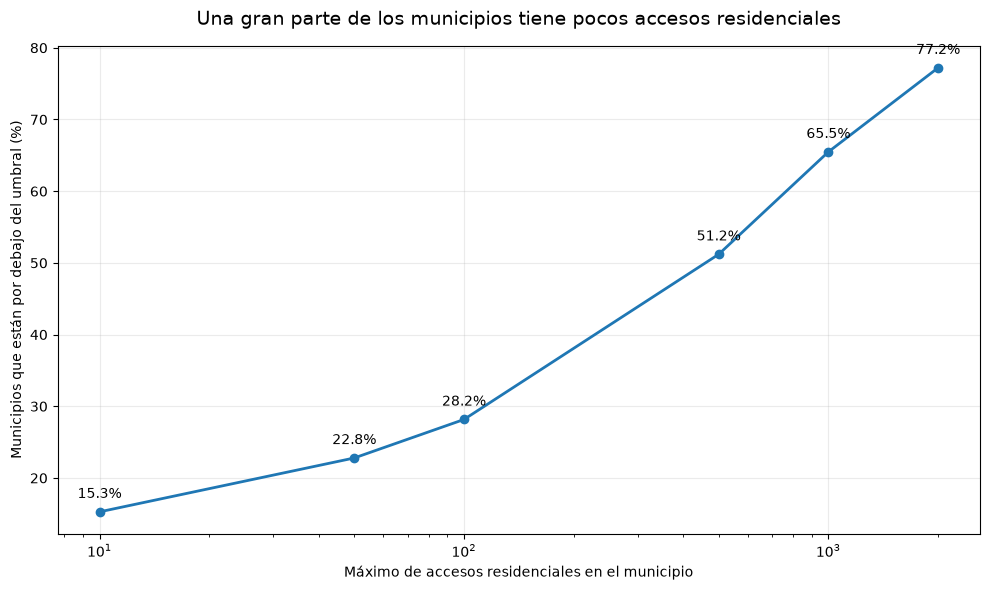

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    distribucion["UMBRAL"],
    distribucion["PORCENTAJE"],
    marker="o",
    linewidth=2
)

for _, fila in distribucion.iterrows():
    ax.annotate(
        f'{fila["PORCENTAJE"]:.1f}%',
        (fila["UMBRAL"], fila["PORCENTAJE"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

ax.set_title(
    "Una gran parte de los municipios tiene pocos accesos residenciales",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Máximo de accesos residenciales en el municipio")
ax.set_ylabel("Municipios que están por debajo del umbral (%)")

ax.set_xscale("log")

ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

Calcular concentración

In [30]:
# Accesos residenciales 2025 por municipio
concentracion = municipios_pivot[
    ["MUNICIPIO", "DEPARTAMENTO", "ACCESOS_2025"]
].copy()

# Ordenar de mayor a menor
concentracion = concentracion.sort_values(
    "ACCESOS_2025",
    ascending=False
).reset_index(drop=True)

# Participación sobre el total
total_accesos = concentracion["ACCESOS_2025"].sum()

concentracion["PARTICIPACION_%"] = (
    concentracion["ACCESOS_2025"] / total_accesos * 100
)

# Participación acumulada
concentracion["ACUMULADO_%"] = (
    concentracion["PARTICIPACION_%"].cumsum()
)

concentracion.head(20)

,MUNICIPIO,DEPARTAMENTO,ACCESOS_2025,PARTICIPACION_%,ACUMULADO_%
0,BOGOTÁ,BOGOTÁ D.C.,"2,250,053.00",24.26,24.26
1,MEDELLÍN,ANTIOQUIA,"775,850.00",8.37,32.63
2,CALI,VALLE DEL CAUCA,"518,607.00",5.59,38.22
3,BARRANQUILLA,ATLÁNTICO,"276,618.00",2.98,41.20
4,CARTAGENA,BOLÍVAR,"247,160.00",2.67,43.87
5,SOACHA,CUNDINAMARCA,"193,189.00",2.08,45.95
6,IBAGUÉ,TOLIMA,"190,276.00",2.05,48.00
7,BELLO,ANTIOQUIA,"176,311.00",1.90,49.90
8,BUCARAMANGA,SANTANDER,"141,150.00",1.52,51.43
9,CÚCUTA,NORTE SANTANDER,"132,385.00",1.43,52.85


In [31]:
puntos = [1, 5, 10, 20, 50, 100, 200, 500]

resumen_concentracion = pd.DataFrame({
    "MUNICIPIOS": puntos,
    "ACCESOS_ACUMULADOS_%": [
        concentracion.loc[n-1, "ACUMULADO_%"]
        for n in puntos
    ]
})

resumen_concentracion

,MUNICIPIOS,ACCESOS_ACUMULADOS_%
0,1,24.26
1,5,43.87
2,10,52.85
3,20,64.10
4,50,79.64
5,100,88.09
6,200,93.52
7,500,98.50


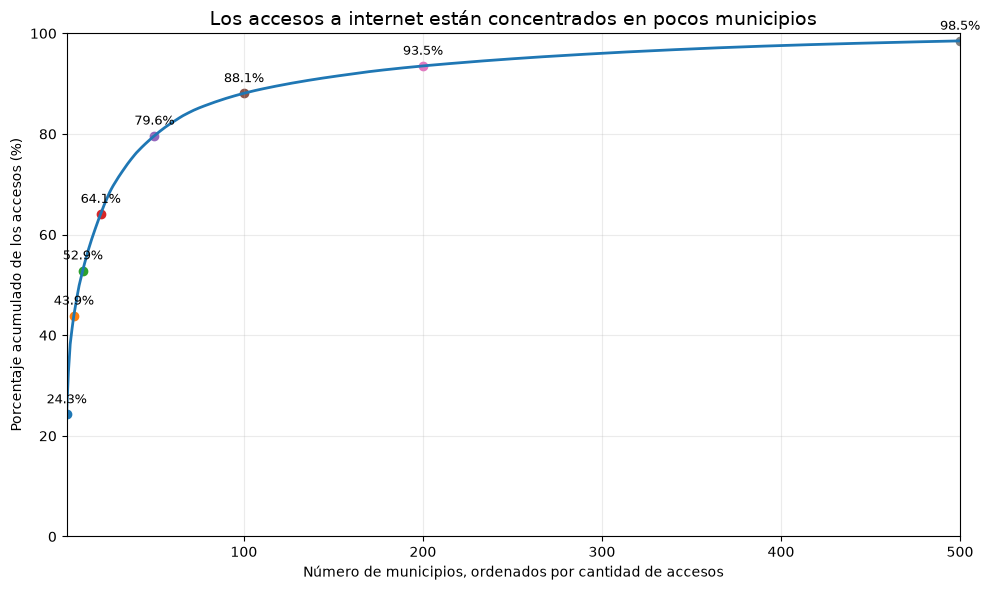

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    concentracion.index + 1,
    concentracion["ACUMULADO_%"],
    linewidth=2
)

for n in puntos:
    valor = concentracion.loc[n-1, "ACUMULADO_%"]
    
    ax.scatter(n, valor)
    
    ax.annotate(
        f"{valor:.1f}%",
        (n, valor),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_title(
    "Los accesos a internet están concentrados en pocos municipios",
    fontsize=14
)

ax.set_xlabel("Número de municipios, ordenados por cantidad de accesos")
ax.set_ylabel("Porcentaje acumulado de los accesos (%)")

ax.set_xlim(1, 500)
ax.set_ylim(0, 100)

ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [33]:
concentracion.head(20)[
    ["MUNICIPIO", "DEPARTAMENTO", "ACCESOS_2025", "PARTICIPACION_%"]
]

,MUNICIPIO,DEPARTAMENTO,ACCESOS_2025,PARTICIPACION_%
0,BOGOTÁ,BOGOTÁ D.C.,"2,250,053.00",24.26
1,MEDELLÍN,ANTIOQUIA,"775,850.00",8.37
2,CALI,VALLE DEL CAUCA,"518,607.00",5.59
3,BARRANQUILLA,ATLÁNTICO,"276,618.00",2.98
4,CARTAGENA,BOLÍVAR,"247,160.00",2.67
5,SOACHA,CUNDINAMARCA,"193,189.00",2.08
6,IBAGUÉ,TOLIMA,"190,276.00",2.05
7,BELLO,ANTIOQUIA,"176,311.00",1.90
8,BUCARAMANGA,SANTANDER,"141,150.00",1.52
9,CÚCUTA,NORTE SANTANDER,"132,385.00",1.43


4. ¿Qué cambios han experimentado los territorios con mayor crecimiento de conectividad?

¿Qué patrones de crecimiento, retroceso y recuperación de la conectividad se observan en los territorios colombianos?

In [34]:
print("TOP 20 — MAYOR CRECIMIENTO ABSOLUTO")
display(top_absoluto)

print("\nTOP 20 — MAYOR CRECIMIENTO PORCENTUAL")
display(top_crecimiento)

TOP 20 — MAYOR CRECIMIENTO ABSOLUTO


,MUNICIPIO,DEPARTAMENTO,ACCESOS_2017,ACCESOS_2025,CAMBIO_ABSOLUTO,CAMBIO_%
0,MEDELLÍN,ANTIOQUIA,"519,915.00","775,850.00","255,935.00",49.23
158,CARTAGENA,BOLÍVAR,"127,060.00","247,160.00","120,100.00",94.52
579,SOACHA,CUNDINAMARCA,"86,653.00","193,189.00","106,536.00",122.95
1050,IBAGUÉ,TOLIMA,"93,005.00","190,276.00","97,271.00",104.59
1099,CALI,VALLE DEL CAUCA,"421,691.00","518,607.00","96,916.00",22.98
133,BARRANQUILLA,ATLÁNTICO,"191,735.00","276,618.00","84,883.00",44.27
18,BELLO,ANTIOQUIA,"94,884.00","176,311.00","81,427.00",85.82
696,SANTA MARTA,MAGDALENA,"65,186.00","119,935.00","54,749.00",83.99
919,PEREIRA,RISARALDA,"81,092.00","129,232.00","48,140.00",59.36
434,VALLEDUPAR,CESAR,"52,728.00","99,434.00","46,706.00",88.58



TOP 20 — MAYOR CRECIMIENTO PORCENTUAL


,MUNICIPIO,DEPARTAMENTO,ACCESOS_2017,ACCESOS_2025,CAMBIO_ABSOLUTO,CAMBIO_%
1172,PUERTO CAICEDO,PUTUMAYO,1.00,"1,783.00","1,782.00","178,200.00"
1177,SAN MIGUEL,PUTUMAYO,1.00,"1,541.00","1,540.00","154,000.00"
444,EL PASO,CESAR,1.00,"1,351.00","1,350.00","135,000.00"
670,SALADOBLANCO,HUILA,2.00,"2,418.00","2,416.00","120,800.00"
709,GUAMAL,MAGDALENA,1.00,"1,199.00","1,198.00","119,800.00"
648,ALGECIRAS,HUILA,3.00,"2,167.00","2,164.00","72,133.33"
413,PAEZ,CAUCA,2.00,"1,059.00","1,057.00","52,850.00"
725,TENERIFE,MAGDALENA,1.00,485.00,484.00,"48,400.00"
652,COLOMBIA,HUILA,1.00,469.00,468.00,"46,800.00"
684,DIBULLA,LA GUAJIRA,1.00,396.00,395.00,"39,500.00"


5. ¿La conectividad se relaciona con otras variables socioeconómicas?

¿Qué relación existe entre el nivel de conectividad y las condiciones socioeconómicas de los territorios?

In [39]:
from pathlib import Path

ROOT = Path(r"C:\Users\USUARIO\Desktop\Colombia_en_datos")

print("Raíz:", ROOT)
print("¿Existe?:", ROOT.exists())

# Excluir carpetas que generan falsos positivos o archivos innecesarios.
excluir = {
    ".git",
    ".venv",
    "venv",
    "__pycache__",
    ".ipynb_checkpoints",
    "node_modules"
}

extensiones = {
    ".csv", ".xlsx", ".xls", ".parquet",
    ".json", ".dta", ".sav", ".ods", ".pdf"
}

archivos = [
    archivo
    for archivo in ROOT.rglob("*")
    if (
        archivo.is_file()
        and archivo.suffix.lower() in extensiones
        and not any(parte in excluir for parte in archivo.parts)
    )
]

print(f"Archivos de datos dentro del proyecto: {len(archivos)}")

# Primero buscar únicamente coincidencias específicas de IPM.
terminos_ipm = (
    "ipm",
    "pobreza_multidimensional",
    "pobreza-multidimensional",
    "multidimensional"
)

candidatos_ipm = [
    archivo
    for archivo in archivos
    if any(termino in archivo.name.lower() for termino in terminos_ipm)
]

print(f"\nArchivos cuyo nombre menciona IPM o pobreza multidimensional: {len(candidatos_ipm)}")

for archivo in candidatos_ipm:
    print(archivo.relative_to(ROOT))

Raíz: C:\Users\USUARIO\Desktop\Colombia_en_datos
¿Existe?: True
Archivos de datos dentro del proyecto: 55

Archivos cuyo nombre menciona IPM o pobreza multidimensional: 0


In [40]:
terminos_contenido = (
    "ipm",
    "índice de pobreza multidimensional",
    "indice de pobreza multidimensional",
    "pobreza multidimensional"
)

extensiones_texto = {".csv", ".json", ".txt", ".md"}

coincidencias_contenido = []

for archivo in archivos:
    if archivo.suffix.lower() not in extensiones_texto:
        continue

    try:
        texto = archivo.read_text(
            encoding="utf-8",
            errors="ignore"
        ).lower()

        encontrados = [
            termino
            for termino in terminos_contenido
            if termino in texto
        ]

        if encontrados:
            coincidencias_contenido.append(
                (archivo, encontrados)
            )

    except Exception:
        pass

print(
    f"Archivos cuyo contenido menciona IPM o pobreza multidimensional: "
    f"{len(coincidencias_contenido)}"
)

for archivo, encontrados in coincidencias_contenido:
    print(f"{archivo.relative_to(ROOT)} → {encontrados}")

Archivos cuyo contenido menciona IPM o pobreza multidimensional: 21
episodios\002_EL_chocó\Data\processed\auditoria_variables_etapa_2_1.csv → ['ipm', 'índice de pobreza multidimensional', 'pobreza multidimensional']
episodios\002_EL_chocó\Data\processed\cobertura_candidatas_etapa_2_1.csv → ['ipm']
episodios\002_EL_chocó\Data\processed\cobertura_variables_etapa_3_iot.csv → ['ipm']
episodios\002_EL_chocó\Data\processed\cobertura_variables_iot.csv → ['ipm']
episodios\002_EL_chocó\Data\processed\comparabilidad_temporal_etapa_2_1.csv → ['ipm']
episodios\002_EL_chocó\Data\processed\comparabilidad_temporal_etapa_3_iot.csv → ['ipm']
episodios\002_EL_chocó\Data\processed\correlaciones_candidatas_etapa_2_1.csv → ['ipm']
episodios\002_EL_chocó\Data\processed\correlaciones_variables_etapa_3_iot.csv → ['ipm']
episodios\002_EL_chocó\Data\processed\dataset_analitico_etapa_3_iot.csv → ['ipm']
episodios\002_EL_chocó\Data\processed\dataset_analitico_preliminar_iot.csv → ['ipm']
episodios\002_EL_chocó\Da

6. ¿Las personas conectadas utilizan internet de manera diferente?

¿Existen diferencias territoriales en la forma en que las personas utilizan internet?

7. ¿Existe una diferencia territorial en el uso de herramientas de inteligencia artificial?

¿Existe una brecha territorial en el uso de herramientas de inteligencia artificial?

8. ¿Podemos encontrar evidencia de que la expansión de la conectividad estuvo acompañada de cambios económicos o sociales?

¿Los territorios que experimentaron mayores cambios en conectividad también presentaron cambios en indicadores económicos y sociales?